# Realtime-Agent-Framework
- uses Banking77 Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [4]:
df.shape

(10003, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10003 non-null  object
 1   category  10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [6]:
df['category'].nunique()

77

In [7]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

In [8]:
df.head()

,text,category,label
0,I am still waiting on my card?,card_arrival,12
1,What can I do if my card still hasn't arrived ...,card_arrival,12
2,I have been waiting over a week. Is the card s...,card_arrival,12
3,Can I track my card while it is in the process...,card_arrival,12
4,"How do I know if I will get my card, or if it ...",card_arrival,12


In [9]:
df[['category','label']].head()

,category,label
0,card_arrival,12
1,card_arrival,12
2,card_arrival,12
3,card_arrival,12
4,card_arrival,12


In [10]:
label_encoder.classes_[4]

'atm_support'

In [11]:
df = df.drop(columns=['category'])

In [12]:
test_df = pd.read_csv("../data/test.csv")

In [13]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      3080 non-null   object
 1   category  3080 non-null   object
dtypes: object(2)
memory usage: 48.2+ KB


In [14]:
test_df.shape

(3080, 2)

In [15]:
# train test split
X_train = df['text']
y_train = df['label']

# transform category into label for test dataset
test_df['label'] = label_encoder.transform(test_df['category'])
test_df = test_df.drop(columns=['category'])

X_test = test_df['text']
y_test = test_df['label']

In [16]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

10003 10003
3080 3080


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range= (1,2), # bigrams helps a LOT to understand the context from the data
    min_df= 2, # ignore noises
    max_df= 0.9, # it ignores ultra common words
    sublinear_tf= True, # Apply sublinear tf scaling, i.e. replace tf with 1 + log(tf)
)

In [18]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [19]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [20]:
y_pred = model.predict(X_test_tfidf)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8905844155844156

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        40
           1       0.95      0.95      0.95        40
           2       0.95      1.00      0.98        40
           3       1.00      1.00      1.00        40
           4       0.90      0.90      0.90        40
           5       1.00      0.97      0.99        40
           6       0.67      0.75      0.71        40
           7       0.90      0.93      0.91        40
           8       0.93      0.95      0.94        40
           9       0.93      0.95      0.94        40
          10       0.95      0.95      0.95        40
          11       0.87      0.85      0.86        40
          12       0.89      0.85      0.87        40
          13       0.87      0.85      0.86        40
          14       0.95      0.97      0.96        40
          15       0.71      0.88      0.79        40
          16       0.95    

In [22]:
cm = confusion_matrix(y_test, y_pred)


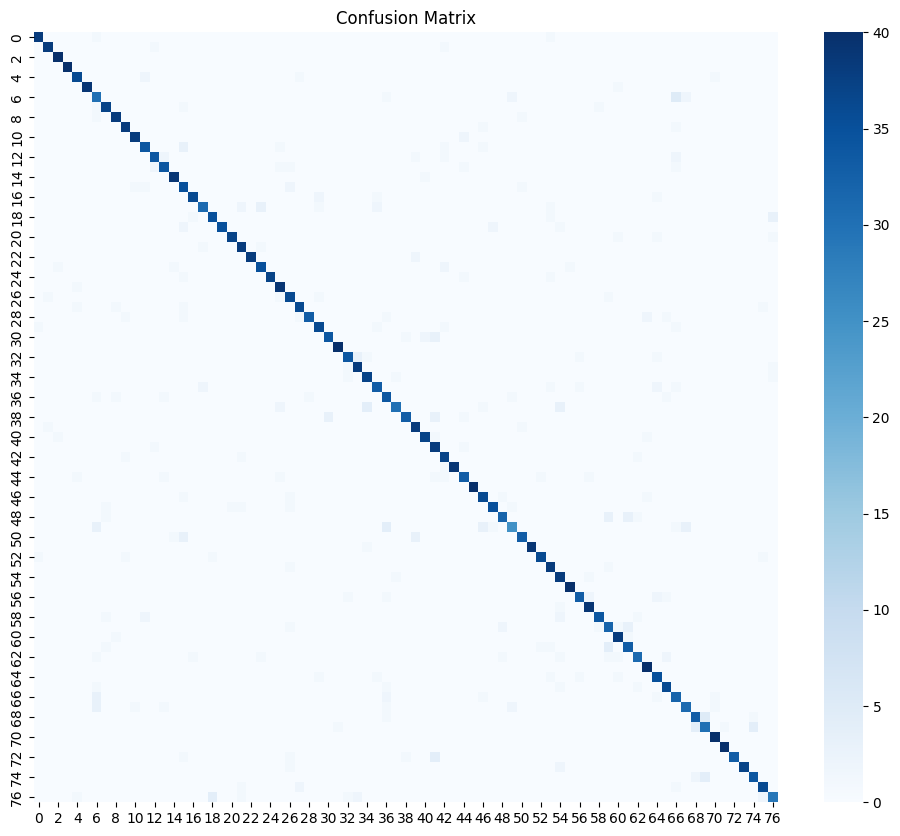

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import joblib
joblib.

ModuleNotFoundError: No module named 'j'

## Improvements use gridsearchcv

In [ ]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "C": [0.1, 0.5, 1, 2, 5]
# }

# grid = GridSearchCV(
#     LinearSVC(),
#     param_grid,
#     cv=5,
#     n_jobs=-1
# )

# grid.fit(X_train_tfidf, y_train)

# best_model = grid.best_estimator_


In [ ]:
# y_pred = best_model.predict(X_test_tfidf)


In [ ]:
# y_pred_labels = label_encoder.inverse_transform(y_pred)
# 